In [1]:
import ModelViz
from sklearn.cluster import KMeans
from sklearn import metrics
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature
from matplotlib.transforms import ScaledTranslation
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.ticker as mticker

import matplotlib as mpl
import matplotlib

import pathlib
from netCDF4 import Dataset as DS


Create an instance of the ModelViz class, then use the functions to 
* `load_data / load_mfdata` to load data
* `load_grid` to load grid information
* `summarise_features` to sum sets of variables together
* `preprocess` to strip boundary and normalise 
* `make_tsds` to reshape data into a time series data set (tsds)
* `load_tsds` to load an existing time series data set from csv
* `train` to create a clustering model
* `load_model` to load an existing model
* `predict` to create predictions based on a tsds and model
* `get_cluster_info` to summarise predictions and calcuate mean/std dev for each cluster
* `plot_map` to plot the cluster output as a map
* `plot_ts` to plot time series for each cluster


## Train the model

Create an instace of ModelViz for the training data, read in that data and grid info
Combine variables and preprocess - stripping the boundary layers and normalising
Make the dataset by reshaping the data into the form needed 
Fit the model

In [2]:
def cluster_var_names(classification):
    train = ModelViz.ModelViz()

    # weird formatting of my data....
    train.x_strip = slice(15,-15)
    train.y_strip = slice(15,-15)
    train.n_init = 100 #0
    train.seed = 800
    train.norm = 'stdev'
    if classification == 'physics':
        train.cluster_vars = ['votemper','vosaline','mldr10_1','PAR']
        train.plot_vars={'votemper':'Temperature','vosaline':'Salinity','mldr10_1':'Mixed layer\ndepth','PAR':'PAR'}
    if classification == 'biogeo':
        train.cluster_vars = ['N1_p','N3_n','N4_n','N5_s','O2_o','O3_c','O3_TA']  #['N1_p','N3_n','O2_o','O3_c','O3_TA','N4_n','N5_s']
        train.plot_vars={'N1_p':'Phosphate','N3_n':'Nitrate','O2_o':'Oxygen','O3_c':'DIC','O3_TA':'Alk.', 'N4_n':'Ammon.', 'N5_s':'Silicate'}
    if classification == 'benthic':
        train.cluster_vars = ['Y2_c','Y3_c','Y4_c','H1_c','H2_c','Q1_c','Q6_c']
        train.plot_vars = {'Y2_c':'Deposit\nfeeders','Y3_c':'Suspens.\nfeeders','Y4_c':'Meiofauna','H1_c':'Aerobic\nbac','H2_c':'Anaerobic\nbac','Q1_c':'DOC','Q6_c':'POC'}
    if classification == 'ecosys':
        train.cluster_vars = ['Phytoplankton','Zooplankton','DOC','POC','B1_c']
        train.plot_vars={'Phytoplankton':'Phytoplank.','Zooplankton':'Zooplank.','DOC':'DOC','POC':'POC','B1_c':'Bacteria'}
    
    filename = '/data/proteus1/scratch/rmi/classifications/COMFORT_data/amm7_mean_2000-2004_'+depth+'_'+classification+'.nc'

    train.load_mfdata(filename)

    train.load_grid('/data/sthenno1/to_archive/yuti/yuti-SSB-AMM7-hindcasts/mesh_mask.nc')

    train.preprocess(do_slice=False)     
    train.make_tsds()
    train.train(n_clusters=6, save=False,model_name = 'kmeans') #, file_path='model.ks')
    train.predict()
    train.get_cluster_info(save=False)
    return train

sum_vars={'Phytoplankton': ['P1_c', 'P2_c', 'P3_c', 'P4_c'],
            'Zooplankton': ['Z4_c', 'Z5_c', 'Z6_c'],
            'DOM': ['R1_c', 'R2_c', 'R3_c'],
            'POM': ['R4_c', 'R6_c', 'R8_c']}

In [5]:
classification = 'physics'
depth = 'surface'

trainphys = cluster_var_names(classification)

metrics.silhouette_score(trainphys.tsds, trainphys.labels,metric='euclidean')


Processing votemper


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 64.70it/s]


Processing vosaline


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 62.97it/s]


Processing mldr10_1


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 64.24it/s]


Processing PAR


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 62.19it/s]


0.4194052119873747

In [31]:
vals = []

for i in range(6):
    val = sum(sum(trainphys.cluster_ds.class_map == i))
    print(round(100*val.values/58004,2))
    vals.append(val.values)
# total is 92115 - 58004 ocean
print(sum(vals))

19.25
19.68
16.85
18.63
2.73
22.87
58004


In [6]:
classification = 'biogeo'
depth = 'surface'

trainbiogeo = cluster_var_names(classification)

metrics.silhouette_score(trainbiogeo.tsds, trainbiogeo.labels,metric='euclidean')


Processing N1_p


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 67.98it/s]


Processing N3_n


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 68.44it/s]


Processing N4_n


...

Processing O3_c


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 65.31it/s]


Processing O3_TA


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 69.70it/s]


0.4102581

In [32]:
vals = []

for i in range(6):
    val = sum(sum(trainbiogeo.cluster_ds.class_map == i))
    print(round(100*val.values/58004,2))
    vals.append(val.values)
# total is 92115 - 58004 ocean
print(sum(vals))

14.2
47.39
1.37
33.38
0.14
3.51
58004


In [4]:
classification = 'ecosys'
depth = 'surface'

traineco = cluster_var_names(classification)

metrics.silhouette_score(traineco.tsds, traineco.labels,metric='euclidean')


Processing Phytoplankton


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 65.18it/s]


Processing Zooplankton


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 67.50it/s]

Processing DOC


...

Processing POC


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 59.64it/s]


Processing B1_c


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 61.38it/s]


0.3753212

In [33]:
vals = []

for i in range(6):
    val = sum(sum(traineco.cluster_ds.class_map == i))
    print(round(100*val.values/58004,2))
    vals.append(val.values)
# total is 92115 - 58004 ocean
print(sum(vals))

30.8
29.01
2.88
4.4
20.98
11.94
58004


Plot data

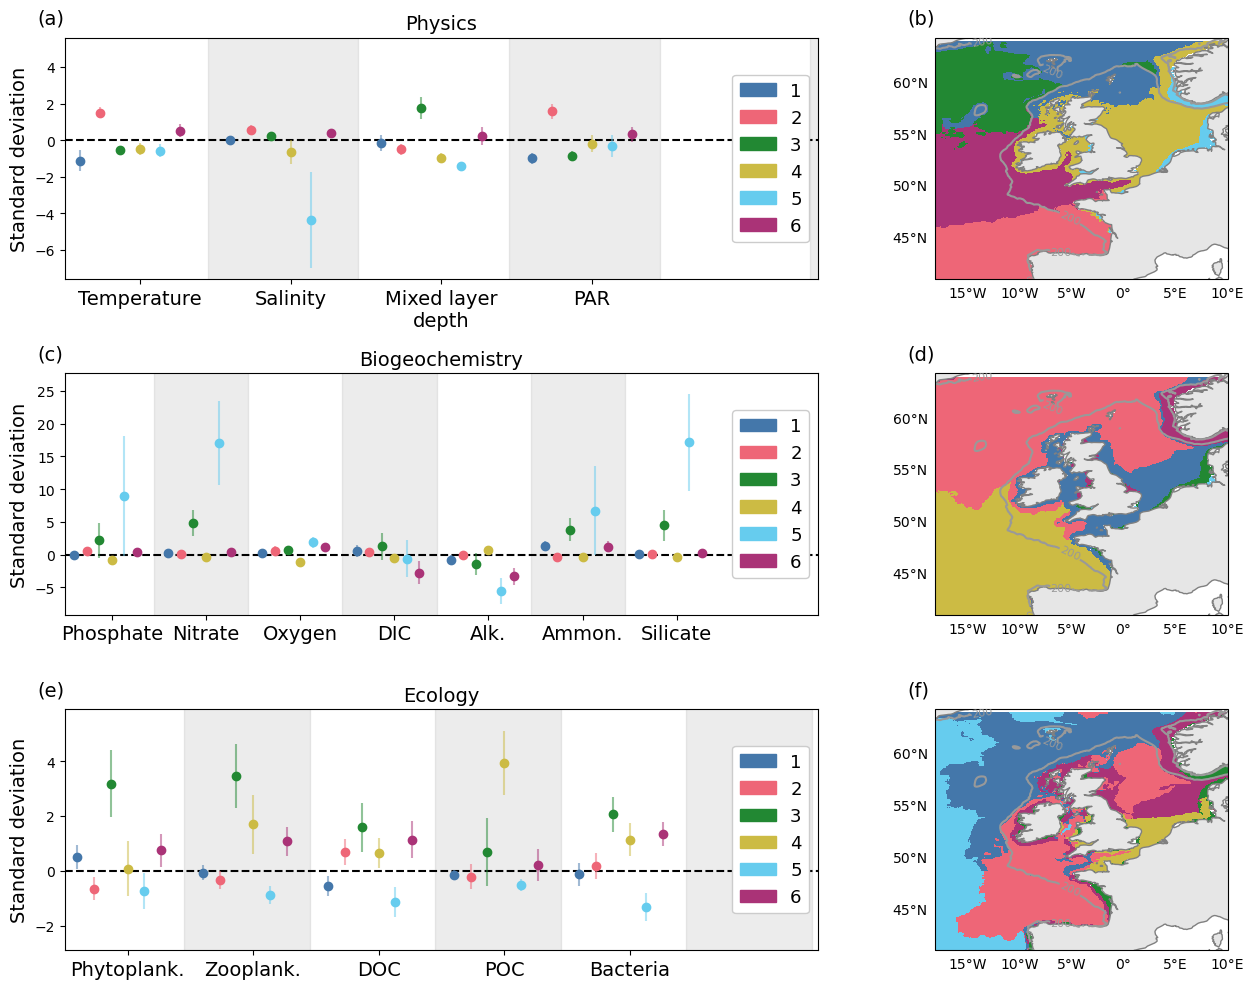

In [14]:
# version 2
vibrant = ['#EE7733', '#0077BB', '#33BBEE', '#EE3377', '#CC3311', '#009988']
bright = ['#4477AA', '#EE6677', '#228833', '#CCBB44', '#66CCEE', '#AA3377']

def plot_map(ax,train,hex_list,title_val,label):
    train.cmap = train.make_cmap(hex_list)
    #hex_list.append(hex_list[-1])
    ax.pcolormesh(train.cluster_ds.lon, train.cluster_ds.lat, train.cluster_ds.class_map, cmap=train.cmap) #,alpha=0.7)
    #plt.contour(train.cluster_ds.lon, train.cluster_ds.lat, train.cluster_ds.class_map,
    #             colors=hex_list, levels = 6)
    # marking out shelf edge
    nc=DS('/data/sthenno1/to_archive/yuti/yuti-SSB-AMM7-hindcasts/mesh_mask.nc') #'/data/sthenno1/scratch/hpo/LOCATE/mesh_mask.nc')
    lon=nc.variables['nav_lon']
    lat=nc.variables['nav_lat']
    bath=nc.variables['gdept_0'][:,-1]
    #not sure what this was doing
    bath_data=np.ma.masked_where(bath[0]==10.1,bath[0])

    extent=[-18.22224,10.11081,41.06672,64.0012]
    ax.set_extent(extent)
    # add contours
    CS=ax.contour(lon[:],lat[:],bath_data, levels=[200],colors='0.6')
    ax.clabel(CS, inline=True, fontsize=8)
    
    ax.add_feature(NaturalEarthFeature(category="physical", facecolor=[0.9, 0.9, 0.9], name="coastline", scale="50m"),
                   edgecolor="gray")
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.0, color="gray", linestyle="-")
    gl.top_labels = False
    gl.bottom_labels = True
    gl.right_labels = False
    gl.left_labels = True
    gl.ylocator = mticker.FixedLocator([45,50,55,60])

    ax.set_aspect("equal")
    ax.text(
    0.0, 1.0, label, transform=(
        ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
    fontsize=14, va='bottom')

def plot_vars(ax,train,hex_list,title_val,label,ymin,ymax):
    patch1 = mpatches.Patch(color=hex_list[0], label='1') #'North')
    patch2 = mpatches.Patch(color=hex_list[1], label='2') #'South')
    patch3 = mpatches.Patch(color=hex_list[2], label='3') #'Shelf')
    patch4 = mpatches.Patch(color=hex_list[3], label='4') #'German bight')
    patch5 = mpatches.Patch(color=hex_list[4], label='5') #'Coastal 1')
    patch6 = mpatches.Patch(color=hex_list[5], label='6') #'Coastal 2')


    train.cmap_discrete = bright

    ax.hlines(0,0,len(train.plot_vars)+2,linestyle='--',color='black')
    ax.fill_between([0.95,1.95], ymin, ymax, 
                    color='grey', alpha=0.15, transform=ax.get_xaxis_transform())
    ax.fill_between([2.95,3.95], ymin, ymax, 
                    color='grey', alpha=0.15, transform=ax.get_xaxis_transform())
    ax.fill_between([4.95,5.95], ymin, ymax, 
                    color='grey', alpha=0.15, transform=ax.get_xaxis_transform())
    for i in range(train.model.n_clusters):
        x_tick_labels = np.asarray([])
        increment = 0.8*(i-train.model.n_clusters/2)/train.model.n_clusters
        for v,var in enumerate(train.plot_vars):
            xbar = train.cluster_ds.class_TS.sel(var=var,vclass=i)
            xstd = train.cluster_ds.class_TS_std.sel(var=var,vclass=i)
            ax.plot(v+0.5+increment,xbar,'o',label=train.plot_vars[var],c=train.cmap_discrete[i])
            ax.errorbar(v+0.5+increment,xbar,xstd,alpha=0.5,color=train.cmap_discrete[i])
            x_tick_labels = np.append(x_tick_labels,[train.plot_vars[var]])
        ax.set_xlim([0,v+2])
        ax.set_xticks(np.linspace(0.5,v+0.5,v+1),x_tick_labels,fontsize=14)
    ax.set_ylabel('Standard deviation',fontsize=14)
    ax.set_title(title_val,fontsize=14)
    ax.text(
    0.0, 1.0, label, transform=(
        ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
    fontsize=14, va='bottom')
    ax.legend(handles=[patch1, patch2,patch3,patch4,patch5,patch6],
              bbox_to_anchor=(1,0.5),loc='center right',facecolor='white', 
              framealpha=1,fontsize=13)
    #ax5.legend(handles=[patch1, patch2,patch3,patch4,patch5,patch6],
    #bbox_to_anchor=(1,0.5),loc='center right',facecolor='white', framealpha=1,fontsize=13)
    #ax5.axis('off')
    
fig = plt.figure(layout="constrained",figsize=[13.5,10])

gs = GridSpec(3, 10, figure=fig)
ax1 = fig.add_subplot(gs[0, 6:], projection = ccrs.PlateCarree())
plot_map(ax1,trainphys,bright,'Physics','(b)')
ax2 = fig.add_subplot(gs[1, 6:], projection = ccrs.PlateCarree())
plot_map(ax2,trainbiogeo,bright,'Biogeochemistry','(d)')
ax3 = fig.add_subplot(gs[2, 6:], projection = ccrs.PlateCarree())
plot_map(ax3,traineco,bright,'Ecology','(f)')
ax4 = fig.add_subplot(gs[0, 0:6])
plot_vars(ax4,trainphys,bright,'Physics','(a)',-5,5)
ax5 = fig.add_subplot(gs[1, 0:6])
plot_vars(ax5,trainbiogeo,bright,'Biogeochemistry','(c)',-7,26)
ax6 = fig.add_subplot(gs[2, 0:6])
plot_vars(ax6,traineco,bright,'Ecology','(e)',-2.5,5.5)
#plt.show()

plt.tight_layout()
plt.savefig('figure 1 new.png')

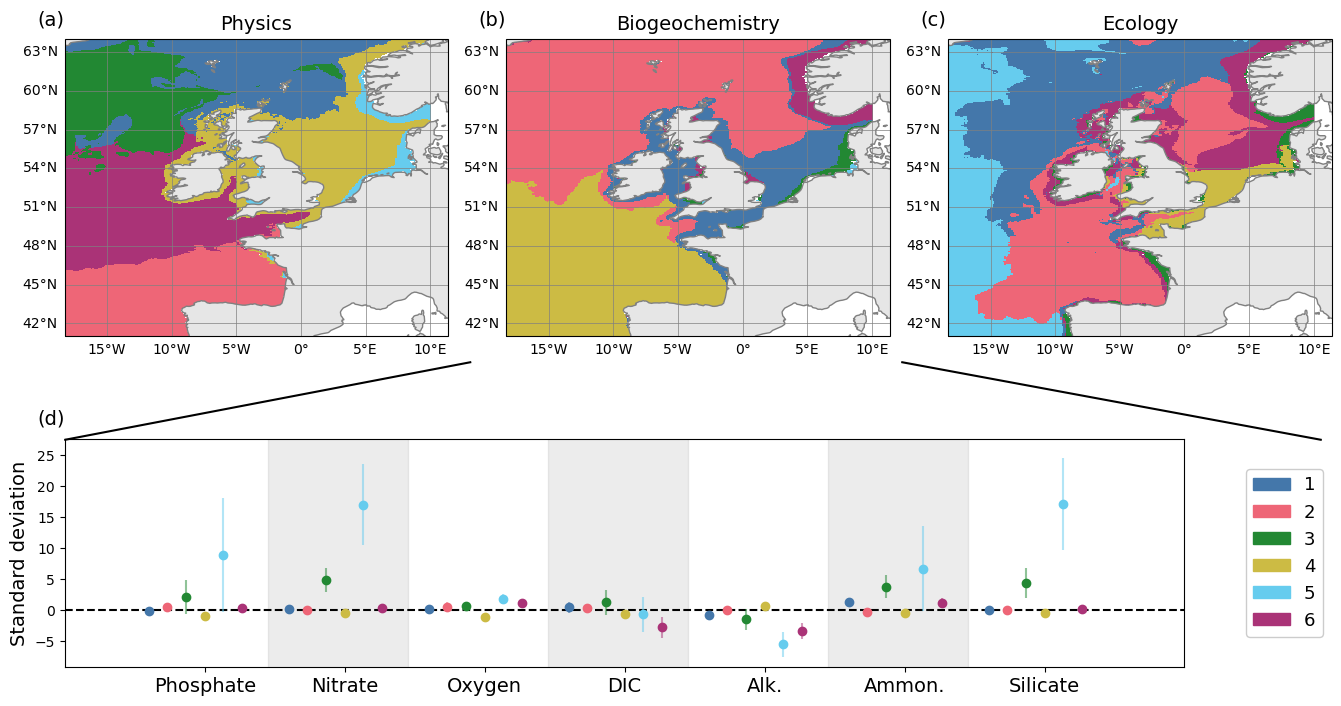

In [38]:
# Old version
vibrant = ['#EE7733', '#0077BB', '#33BBEE', '#EE3377', '#CC3311', '#009988']
bright = ['#4477AA', '#EE6677', '#228833', '#CCBB44', '#66CCEE', '#AA3377']

def plot_map(ax,train,hex_list,title_val,label):
    train.cmap = train.make_cmap(hex_list)
    #hex_list.append(hex_list[-1])
    ax.pcolormesh(train.cluster_ds.lon, train.cluster_ds.lat, train.cluster_ds.class_map, cmap=train.cmap) #,alpha=0.7)
    #plt.contour(train.cluster_ds.lon, train.cluster_ds.lat, train.cluster_ds.class_map,
    #             colors=hex_list, levels = 6)
    ax.add_feature(NaturalEarthFeature(category="physical", facecolor=[0.9, 0.9, 0.9], name="coastline", scale="50m"),
                   edgecolor="gray")
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.5, color="gray", linestyle="-")
    gl.top_labels = False
    gl.bottom_labels = True
    gl.right_labels = False
    gl.left_labels = True
    ax.set_aspect("equal")
    ax.set_title(title_val,fontsize=14)
    ax.text(
    0.0, 1.0, label, transform=(
        ax.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
    fontsize=14, va='bottom')

fig = plt.figure(layout="constrained",figsize=[13.5,7.75])

gs = GridSpec(3, 9, figure=fig)
ax1 = fig.add_subplot(gs[0:-1, 0:3], projection = ccrs.PlateCarree())
plot_map(ax1,trainphys,bright,'Physics','(a)')
ax2 = fig.add_subplot(gs[0:-1, 3:6], projection = ccrs.PlateCarree())
plot_map(ax2,trainbiogeo,bright,'Biogeochemistry','(b)')
ax3 = fig.add_subplot(gs[0:-1, 6:], projection = ccrs.PlateCarree())
plot_map(ax3,traineco,bright,'Ecology','(c)')
ax4 = fig.add_subplot(gs[2, 0:-1])
ax5 = fig.add_subplot(gs[2, -1])

#plt.show()


patch1 = mpatches.Patch(color=bright[0], label='1') #'North')
patch2 = mpatches.Patch(color=bright[1], label='2') #'South')
patch3 = mpatches.Patch(color=bright[2], label='3') #'Shelf')
patch4 = mpatches.Patch(color=bright[3], label='4') #'German bight')
patch5 = mpatches.Patch(color=bright[4], label='5') #'Coastal 1')
patch6 = mpatches.Patch(color=bright[5], label='6') #'Coastal 2')


trainbiogeo.cmap_discrete = bright

ax4.hlines(0,0,len(trainbiogeo.plot_vars)+2,linestyle='--',color='black')
ax4.fill_between([1.45,2.45], -7, 26, 
                color='grey', alpha=0.15, transform=ax4.get_xaxis_transform())
ax4.fill_between([3.45,4.45], -7, 26, 
                color='grey', alpha=0.15, transform=ax4.get_xaxis_transform())
ax4.fill_between([5.45,6.45], -7, 26, 
                color='grey', alpha=0.15, transform=ax4.get_xaxis_transform())
for i in range(trainbiogeo.model.n_clusters):
    x_tick_labels = np.asarray([])
    increment = 0.8*(i-trainbiogeo.model.n_clusters/2)/trainbiogeo.model.n_clusters
    for v,var in enumerate(trainbiogeo.plot_vars):
        xbar = trainbiogeo.cluster_ds.class_TS.sel(var=var,vclass=i)
        xstd = trainbiogeo.cluster_ds.class_TS_std.sel(var=var,vclass=i)
        ax4.plot(v+1+increment,xbar,'o',label=trainbiogeo.plot_vars[var],c=trainbiogeo.cmap_discrete[i])
        ax4.errorbar(v+1+increment,xbar,xstd,alpha=0.5,color=trainbiogeo.cmap_discrete[i])
        x_tick_labels = np.append(x_tick_labels,[trainbiogeo.plot_vars[var]])
    ax4.set_xlim([0,v+2])
    ax4.set_xticks(range(1,v+2),x_tick_labels,fontsize=14)
ax4.set_ylabel('Standard deviation',fontsize=14)
ax4.text(
0.0, 1.0, '(d)', transform=(
    ax4.transAxes + ScaledTranslation(-20/72, +7/72, fig.dpi_scale_trans)),
fontsize=14, va='bottom')
ax5.legend(handles=[patch1, patch2,patch3,patch4,patch5,patch6],bbox_to_anchor=(1,0.5),loc='center right',facecolor='white', framealpha=1,fontsize=13)
ax5.axis('off')

transFigure = fig.transFigure.inverted()
coord1 = transFigure.transform(ax2.transData.transform([0,0]))
coord2 = transFigure.transform(ax4.transData.transform([0,26]))


fig.add_artist(mpl.lines.Line2D(([ 0.05, 0.35]),([0.35, 0.45]),transform=fig.transFigure,color='black'))
fig.add_artist(mpl.lines.Line2D(([ 0.98, 0.67]),([0.35, 0.45]),transform=fig.transFigure,color='black'))

#fig.lines = line,

plt.tight_layout()
#plt.savefig('figure 1.png')